## General Feature Engineering and Data Exploration

### First Steps

In [ ]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


In [ ]:
# 2. Load dataset
DATA_PATH = Path("../data/raw/airlines_delay.csv")  # <- ggf. Dateinamen anpassen

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (539383, 9)


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


In [ ]:
# 3. Basic overview
print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicated rows:", df.duplicated().sum())


First 5 rows:


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0



Column names:
['id', 'Airline', 'Flight', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Time', 'Length', 'Delay']

Data types:


id              int64
Airline        object
Flight          int64
AirportFrom    object
AirportTo      object
DayOfWeek       int64
Time            int64
Length          int64
Delay           int64
dtype: object


Missing values:


id             0
Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64


Duplicated rows: 0


In [ ]:
# 4. Basic statistics
display(df.describe(include="all")) 


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
count,539383.00000,539383,539383.000000,539383,539383,539383.000000,539383.000000,539383.000000,539383.000000
unique,NaN,18,NaN,293,293,NaN,NaN,NaN,NaN
top,NaN,WN,NaN,ATL,ATL,NaN,NaN,NaN,NaN
freq,NaN,94097,NaN,34449,34440,NaN,NaN,NaN,NaN
mean,269692.00000,NaN,2427.928630,NaN,NaN,3.929668,802.728963,132.202007,0.445442
std,155706.60446,NaN,2067.429837,NaN,NaN,1.914664,278.045911,70.117016,0.497015
min,1.00000,NaN,1.000000,NaN,NaN,1.000000,10.000000,0.000000,0.000000
25%,134846.50000,NaN,712.000000,NaN,NaN,2.000000,565.000000,81.000000,0.000000
50%,269692.00000,NaN,1809.000000,NaN,NaN,4.000000,795.000000,115.000000,0.000000
75%,404537.50000,NaN,3745.000000,NaN,NaN,5.000000,1035.000000,162.000000,1.000000


Target counts:


Delay
0    299119
1    240264
Name: count, dtype: int64

Target percentage:


Delay
0    55.46
1    44.54
Name: proportion, dtype: float64

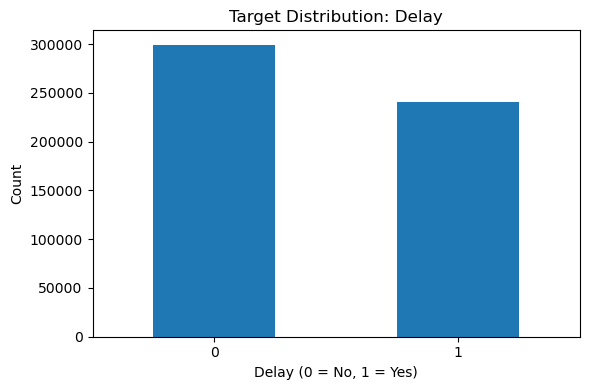

In [ ]:
# 5. Target variable distribution
target_counts = df["Delay"].value_counts().sort_index()
target_ratio = df["Delay"].value_counts(normalize=True).sort_index() * 100

print("Target counts:")
display(target_counts)

print("Target percentage:")
display(target_ratio.round(2))

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Target Distribution: Delay")
plt.xlabel("Delay (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# 6. Unique values per column -> how many different values per column?
unique_values = pd.DataFrame({
    "column": df.columns,
    "n_unique": [df[col].nunique() for col in df.columns]
}).sort_values(by="n_unique", ascending=False)

display(unique_values)


,column,n_unique
0,id,539383
2,Flight,6585
6,Time,1131
7,Length,426
3,AirportFrom,293
4,AirportTo,293
1,Airline,18
5,DayOfWeek,7
8,Delay,2


### First Feature Engineering

In [ ]:
# 7. Feature engineering for EDA
# Time is minutes since midnight (0 = 00:00, 1439 = 23:59)
df_eda = df.copy()

df_eda["DepartureHour"] = df_eda["Time"] // 60 # Integer division gives the hours part.
df_eda["DepartureMinute"] = df_eda["Time"] % 60 # Modulo operator gives the remainder after division, which is the minutes part.
df_eda["IsWeekend"] = df_eda["DayOfWeek"].isin([6, 7]).astype(int) 

print(df_eda[["Time", "DepartureHour", "DepartureMinute", "IsWeekend"]].head())


   Time  DepartureHour  DepartureMinute  IsWeekend
0    15              0               15          0
1    15              0               15          0
2    20              0               20          0
3    20              0               20          0
4    30              0               30          0


In [ ]:
# 8. Sanity checks for engineered columns -> do the values make sense?
print("DepartureHour min/max:", df_eda["DepartureHour"].min(), df_eda["DepartureHour"].max())
print("DepartureMinute min/max:", df_eda["DepartureMinute"].min(), df_eda["DepartureMinute"].max())

invalid_hours = df_eda[(df_eda["DepartureHour"] < 0) | (df_eda["DepartureHour"] > 23)]
invalid_minutes = df_eda[(df_eda["DepartureMinute"] < 0) | (df_eda["DepartureMinute"] > 59)]

print("Invalid hour rows:", len(invalid_hours))
print("Invalid minute rows:", len(invalid_minutes))


DepartureHour min/max: 0 23
DepartureMinute min/max: 0 59
Invalid hour rows: 0
Invalid minute rows: 0


### Exploratory Data Analysis

,count,mean,delay_rate_percent
Airline,,,
WN,94097,0.697759,69.775870
CO,21118,0.566199,56.619945
B6,18112,0.467038,46.703843
OO,50254,0.452899,45.289927
DL,60940,0.450476,45.047588
F9,6456,0.449040,44.903965
EV,27983,0.402208,40.220848
9E,20686,0.397660,39.766025
AA,45656,0.388470,38.847030


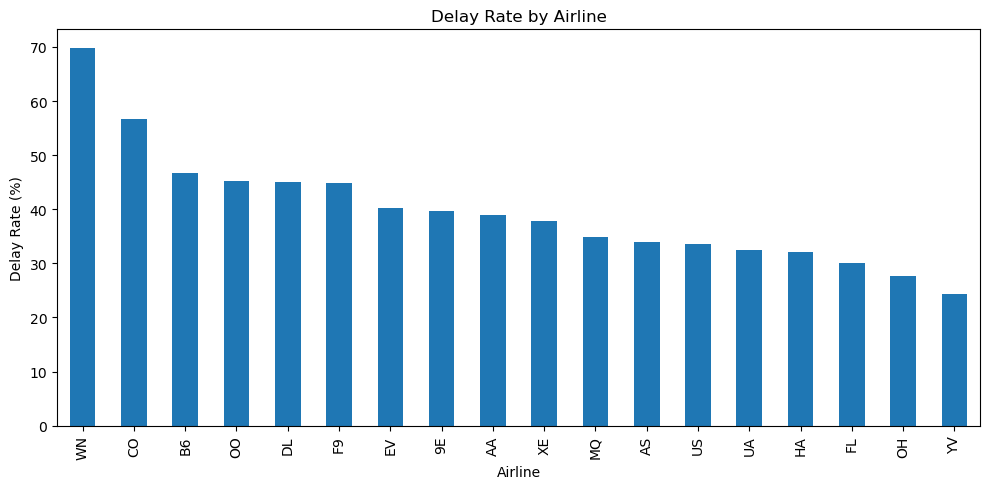

In [ ]:
# 9. Delay rate by airline -> which airlines have the highest delay rates?
airline_delay = (
    df_eda.groupby("Airline")["Delay"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

airline_delay["delay_rate_percent"] = airline_delay["mean"] * 100
display(airline_delay.head(15))

plt.figure(figsize=(10, 5))
airline_delay["delay_rate_percent"].plot(kind="bar")
plt.title("Delay Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay Rate (%)")
plt.tight_layout()
plt.show()


,count,mean,delay_rate_percent
AirportFrom,,,
MDW,7103,0.735182,73.518232
DAL,3838,0.715998,71.599792
OAK,3783,0.712926,71.292625
HOU,4420,0.667195,66.719457
SMF,3504,0.605879,60.587900
SJC,3357,0.587131,58.713137
BWI,8565,0.573263,57.326328
STL,5031,0.568475,56.847545
RNO,1708,0.566159,56.615925


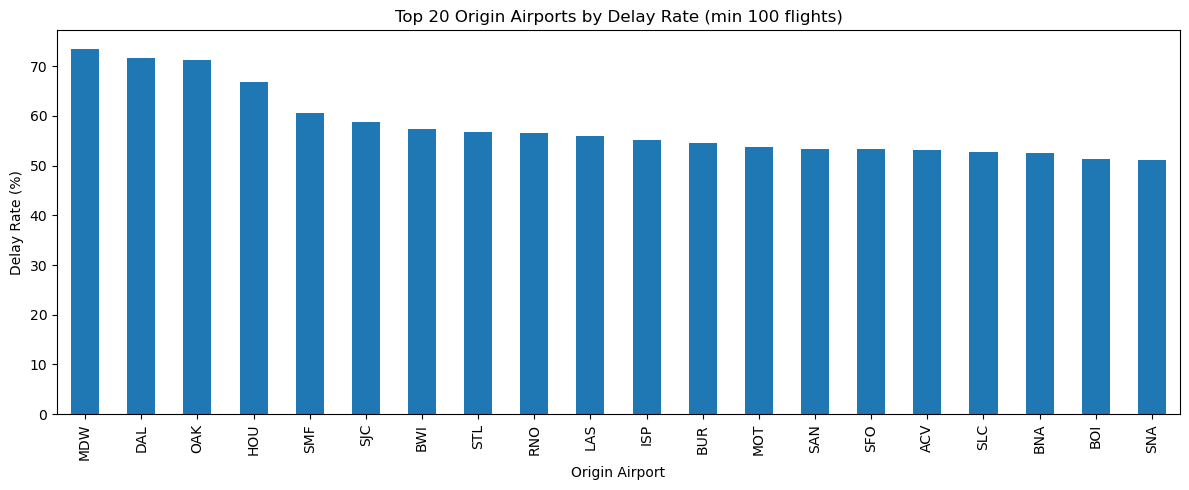

In [ ]:
# 10. Delay rate by origin airport -> which origin airports have the highest delay rates?
origin_delay = (
    df_eda.groupby("AirportFrom")["Delay"]
    .agg(["count", "mean"])
    .sort_values(["count", "mean"], ascending=[False, False])
)

# only airports with enough observations
origin_delay_filtered = origin_delay[origin_delay["count"] >= 100]
origin_delay_filtered = origin_delay_filtered.sort_values("mean", ascending=False).head(20)
origin_delay_filtered["delay_rate_percent"] = origin_delay_filtered["mean"] * 100

display(origin_delay_filtered)

plt.figure(figsize=(12, 5))
origin_delay_filtered["delay_rate_percent"].plot(kind="bar")
plt.title("Top 20 Origin Airports by Delay Rate (min 100 flights)")
plt.xlabel("Origin Airport")
plt.ylabel("Delay Rate (%)")
plt.tight_layout()
plt.show()


,count,mean,delay_rate_percent
AirportTo,,,
OAK,3781,0.637133,63.713303
RDD,120,0.633333,63.333333
ONT,1943,0.630983,63.098302
MDW,7102,0.626021,62.602084
ISP,631,0.625990,62.599049
SMF,3473,0.615606,61.560610
HOU,4419,0.615524,61.552387
BOI,1208,0.612583,61.258278
DAL,3835,0.603129,60.312907


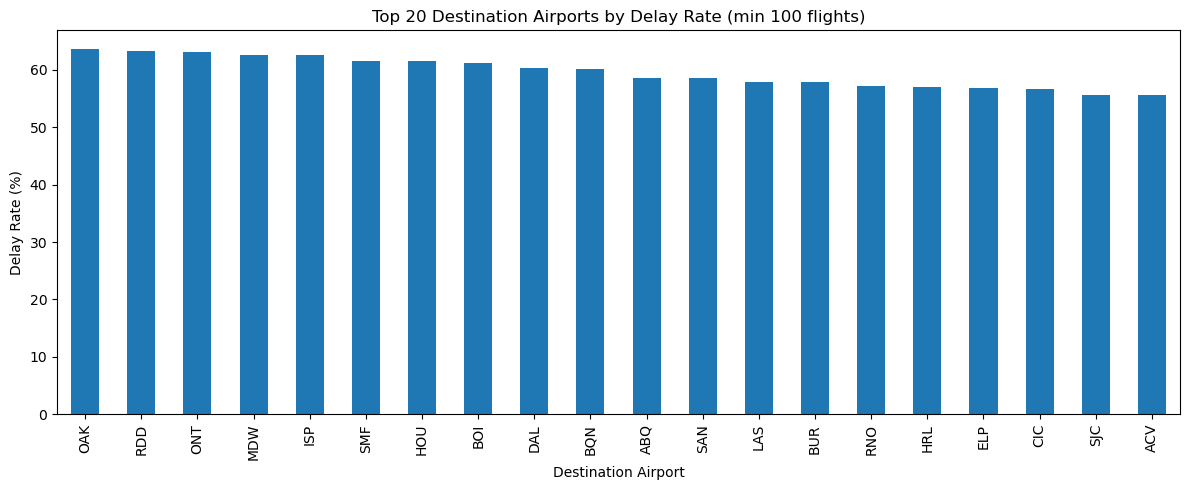

In [ ]:
# 11. Delay rate by destination airport -> which destination airports have the highest delay rates?
dest_delay = (
    df_eda.groupby("AirportTo")["Delay"]
    .agg(["count", "mean"])
    .sort_values(["count", "mean"], ascending=[False, False])
)

dest_delay_filtered = dest_delay[dest_delay["count"] >= 100]
dest_delay_filtered = dest_delay_filtered.sort_values("mean", ascending=False).head(20)
dest_delay_filtered["delay_rate_percent"] = dest_delay_filtered["mean"] * 100

display(dest_delay_filtered)

plt.figure(figsize=(12, 5))
dest_delay_filtered["delay_rate_percent"].plot(kind="bar")
plt.title("Top 20 Destination Airports by Delay Rate (min 100 flights)")
plt.xlabel("Destination Airport")
plt.ylabel("Delay Rate (%)")
plt.tight_layout()
plt.show()


DayOfWeek
Mon    46.764419
Tue    44.733670
Wed    47.081764
Thu    45.102521
Fri    41.660801
Sat    40.055295
Sun    45.354112
Name: Delay, dtype: float64

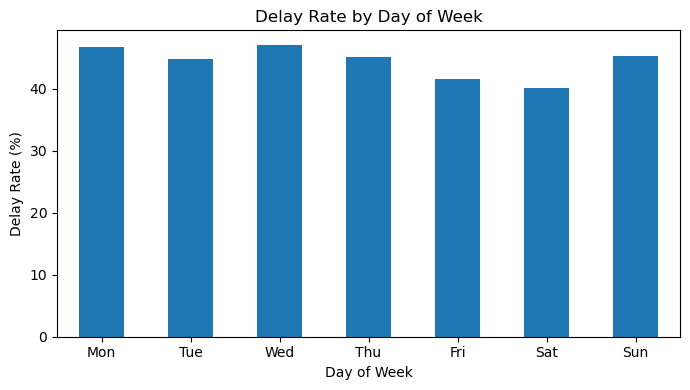

In [ ]:
# 12. Delay rate by day of week -> which days have the highest delay rates?
day_names = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
day_delay = df_eda.groupby("DayOfWeek")["Delay"].mean() * 100
day_delay.index = day_delay.index.map(day_names)
display(day_delay)

plt.figure(figsize=(7, 4))
day_delay.plot(kind="bar")
plt.title("Delay Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


DepartureHour
0     47.132170
1     39.306358
2     44.943820
4     40.404040
5     23.367769
6     25.669729
7     30.205987
8     34.649427
9     40.467551
10    43.663067
11    44.876105
12    46.590000
13    48.324038
14    50.090792
15    51.397961
16    52.136430
17    51.917364
18    53.031255
19    52.142770
20    54.249389
21    48.859913
22    41.679120
23    42.843909
Name: Delay, dtype: float64

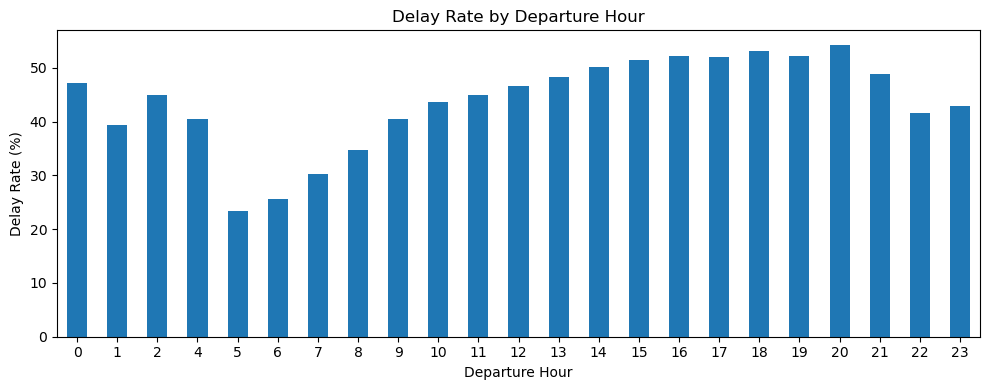

In [ ]:
# 13. Delay rate by departure hour -> which departure hours have the highest delay rates?
hour_delay = df_eda.groupby("DepartureHour")["Delay"].mean() * 100
display(hour_delay)

plt.figure(figsize=(10, 4))
hour_delay.plot(kind="bar")
plt.title("Delay Rate by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


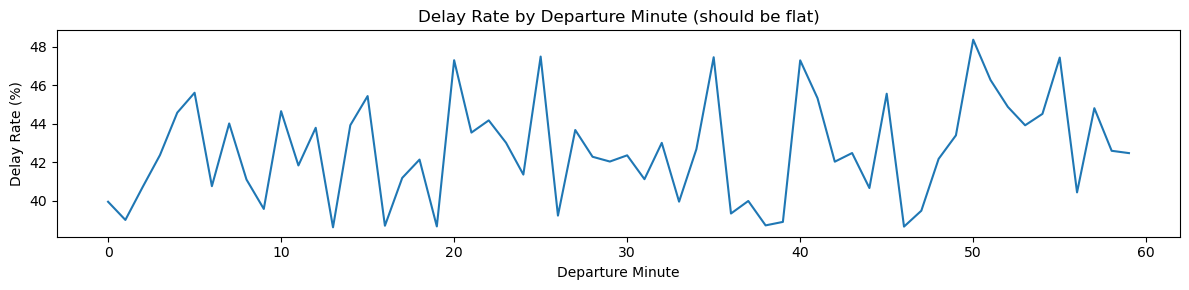

Minute delay rate std: 2.67%
-> DepartureMinute shows no meaningful pattern => dropped from model features.


In [ ]:
# 13b. DepartureMinute signal check
# Check whether departure minute carries any predictive signal.
# If the pattern is flat, we drop it and only keep DepartureHour.
minute_delay = df_eda.groupby("DepartureMinute")["Delay"].mean() * 100

plt.figure(figsize=(12, 3))
minute_delay.plot(kind="line")
plt.title("Delay Rate by Departure Minute (should be flat)")
plt.xlabel("Departure Minute")
plt.ylabel("Delay Rate (%)")
plt.tight_layout()
plt.show()

print(f"Minute delay rate std: {minute_delay.std():.2f}%")
print("-> DepartureMinute shows no meaningful pattern => dropped from model features.")


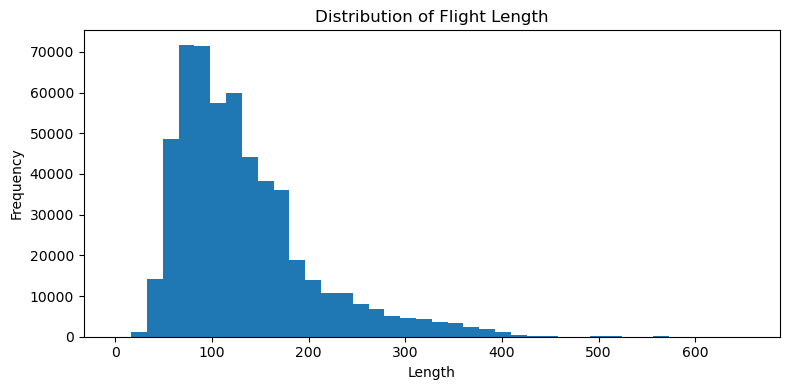

Length summary:


count    539383.000000
mean        132.202007
std          70.117016
min           0.000000
25%          81.000000
50%         115.000000
75%         162.000000
max         655.000000
Name: Length, dtype: float64

In [ ]:
# 14. Flight length distribution
plt.figure(figsize=(8, 4))
plt.hist(df_eda["Length"], bins=40)
plt.title("Distribution of Flight Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Length summary:")
display(df_eda["Length"].describe())


LengthBin
(-0.001, 60.0]    41.250941
(60.0, 120.0]     43.614338
(120.0, 180.0]    43.759427
(180.0, 240.0]    49.863303
(240.0, 360.0]    50.250507
(360.0, 600.0]    44.638640
Name: Delay, dtype: float64

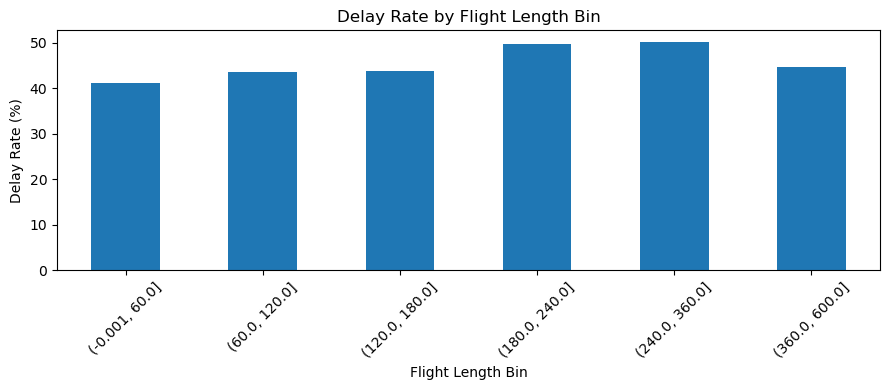

In [ ]:
# 15. Delay rate by flight length bins
df_eda["LengthBin"] = pd.cut(
    df_eda["Length"],
    bins=[0, 60, 120, 180, 240, 360, 600],
    include_lowest=True
)

length_delay = df_eda.groupby("LengthBin", observed=False)["Delay"].mean() * 100
display(length_delay)

plt.figure(figsize=(9, 4))
length_delay.plot(kind="bar")
plt.title("Delay Rate by Flight Length Bin")
plt.xlabel("Flight Length Bin")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Route
LAX-SFO    1079
SFO-LAX    1077
OGG-HNL     982
HNL-OGG     951
SAN-LAX     935
LAX-SAN     935
LAS-LAX     928
LAX-LAS     928
LGA-ATL     916
ATL-LGA     915
LGA-ORD     874
ORD-LGA     842
DFW-ATL     818
ATL-DFW     818
LAX-JFK     812
JFK-LAX     812
LGA-BOS     795
BOS-LGA     795
BOS-DCA     785
DCA-BOS     781
Name: count, dtype: int64

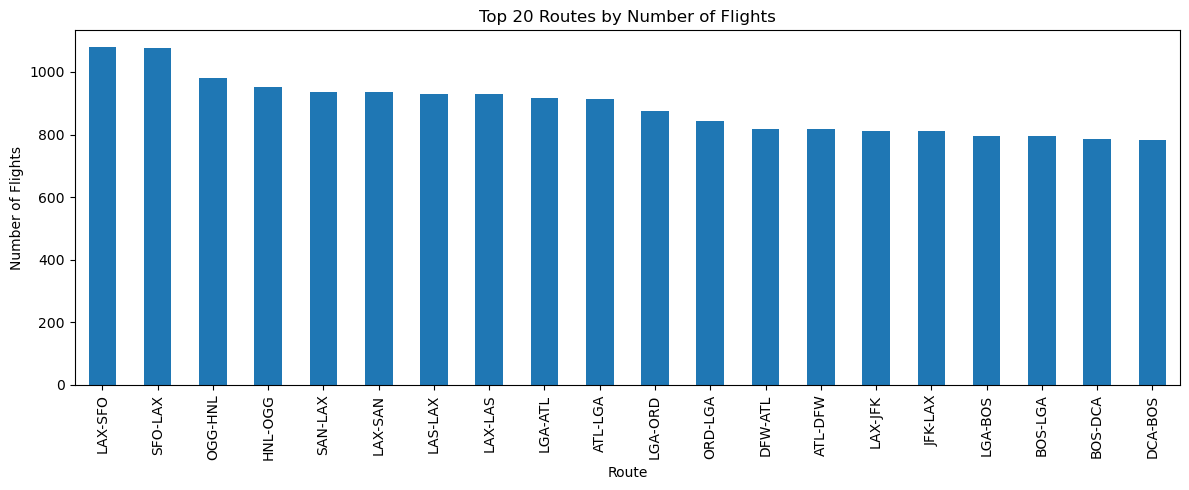

In [ ]:
# 16. Top routes by number of flights
df_eda["Route"] = df_eda["AirportFrom"] + "-" + df_eda["AirportTo"]

top_routes = df_eda["Route"].value_counts().head(20)
display(top_routes)

plt.figure(figsize=(12, 5))
top_routes.plot(kind="bar")
plt.title("Top 20 Routes by Number of Flights")
plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()


,count,mean,delay_rate_percent
Route,,,
LAX-HOU,118,0.889831,88.983051
MDW-OAK,102,0.872549,87.254902
MDW-SAN,117,0.871795,87.179487
HOU-MCO,123,0.869919,86.991870
DAL-ABQ,234,0.858974,85.897436
IAH-LAX,329,0.857143,85.714286
MDW-BUF,117,0.854701,85.470085
SNA-LAS,232,0.844828,84.482759
STL-HOU,109,0.844037,84.403670


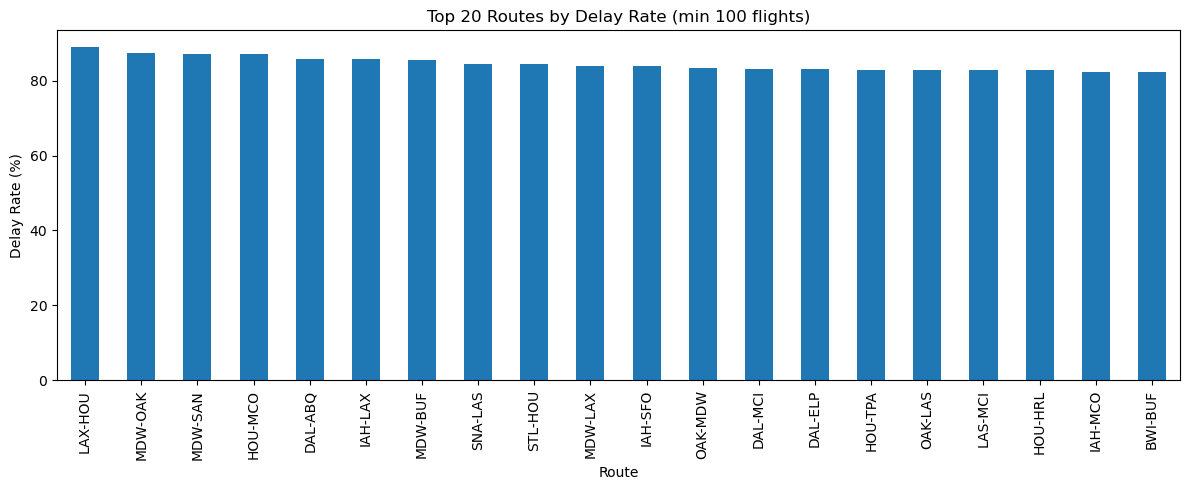

In [ ]:
# 17. Delay rate by route (filtered)
route_delay = (
    df_eda.groupby("Route")["Delay"]
    .agg(["count", "mean"])
)

route_delay_filtered = route_delay[route_delay["count"] >= 100]
route_delay_filtered = route_delay_filtered.sort_values("mean", ascending=False).head(20)
route_delay_filtered["delay_rate_percent"] = route_delay_filtered["mean"] * 100

display(route_delay_filtered)

plt.figure(figsize=(12, 5))
route_delay_filtered["delay_rate_percent"].plot(kind="bar")
plt.title("Top 20 Routes by Delay Rate (min 100 flights)")
plt.xlabel("Route")
plt.ylabel("Delay Rate (%)")
plt.tight_layout()
plt.show()


,DayOfWeek,Length,DepartureHour,Delay
DayOfWeek,1.000000,0.013397,0.001143,-0.026199
Length,0.013397,1.000000,-0.020668,0.040489
DepartureHour,0.001143,-0.020668,1.000000,0.149448
Delay,-0.026199,0.040489,0.149448,1.000000


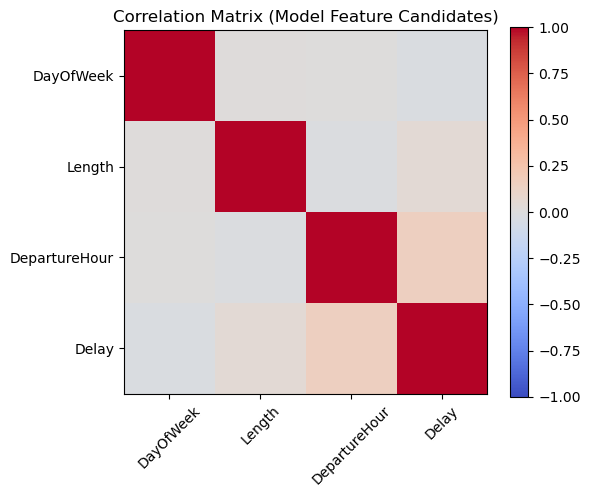

In [ ]:
# 19. Correlation for numeric columns
# Only include final candidate model features + target.
# Time, Flight, and DepartureMinute are excluded (dropped before modeling).
numeric_cols = ["DayOfWeek", "Length", "DepartureHour", "Delay"]

corr = df_eda[numeric_cols].corr(numeric_only=True)
display(corr)

plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation="nearest", vmin=-1, vmax=1, cmap="coolwarm")
plt.title("Correlation Matrix (Model Feature Candidates)")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()


In [ ]:
# 20. Recommended modeling dataset preview

# Final modeling columns:
# - drop id (identifier)
# - drop Flight (high cardinality, weak generalization)
# - drop Time (replaced by DepartureHour)
# - drop DepartureMinute (no predictive signal)
# - drop IsWeekend (redundant with DayOfWeek in model)
# - drop LengthBin (EDA exploration only)
# - drop Route (EDA exploration only)

MODELING_COLS = ["Airline", "AirportFrom", "AirportTo", "DayOfWeek", "Length", "DepartureHour", "Delay"]

model_df = df_eda[MODELING_COLS].copy()

print("Modeling dataset shape:", model_df.shape)
display(model_df.head())
print(model_df.dtypes)


Modeling dataset shape: (539383, 7)


,Airline,AirportFrom,AirportTo,DayOfWeek,Length,DepartureHour,Delay
0,CO,SFO,IAH,3,205,0,1
1,US,PHX,CLT,3,222,0,1
2,AA,LAX,DFW,3,165,0,1
3,AA,SFO,DFW,3,195,0,1
4,AS,ANC,SEA,3,202,0,0


Airline          object
AirportFrom      object
AirportTo        object
DayOfWeek         int64
Length            int64
DepartureHour     int64
Delay             int64
dtype: object


In [ ]:
# 21. Save processed dataset for modeling

# Saves exactly the columns used in modeling + target. Nothing else.
OUTPUT_PATH = Path("../data/processed/airlines_delay_eda.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

model_df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved processed dataset to: {OUTPUT_PATH}")
print(f"Columns saved: {model_df.columns.tolist()}")
print(f"Shape: {model_df.shape}")


Saved processed dataset to: ..\data\processed\airlines_delay_eda.csv
Columns saved: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'DepartureHour', 'Delay']
Shape: (539383, 7)


In [ ]:
# 22. Final EDA summary for presentation

print("EDA SUMMARY")
print("-----------")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Missing values total: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\nTarget distribution (%):")
print((df['Delay'].value_counts(normalize=True) * 100).round(2).sort_index())

print("\nModeling decisions:")
print("- Target: Delay")
print("- Drop: id, Flight, Time, DepartureMinute, IsWeekend, LengthBin, Route")
print("- Time is minutes since midnight -> DepartureHour = Time // 60")
print("- IsWeekend is redundant with DayOfWeek -> excluded from model")
print("- DepartureMinute shows no signal -> excluded from model")
print("- Final features: Airline, AirportFrom, AirportTo, DayOfWeek, Length, DepartureHour")


EDA SUMMARY
-----------
Rows: 539383
Columns: 9
Missing values total: 0
Duplicate rows: 0

Target distribution (%):
Delay
0    55.46
1    44.54
Name: proportion, dtype: float64

Modeling decisions:
- Target: Delay
- Drop: id, Flight, Time, DepartureMinute, IsWeekend, LengthBin, Route
- Time is minutes since midnight -> DepartureHour = Time // 60
- IsWeekend is redundant with DayOfWeek -> excluded from model
- DepartureMinute shows no signal -> excluded from model
- Final features: Airline, AirportFrom, AirportTo, DayOfWeek, Length, DepartureHour
